# Functions to Generate Season 3 PWHL Attendance Dataset

[PWHL Data reference](https://github.com/IsabelleLefebvre97/PWHL-Data-Reference)



In [150]:
pip install requests

In [151]:
import pandas as pd

In [152]:
import requests
def get_game_summary_df_from_id(game_id):
  game_summary_response = requests.get("https://lscluster.hockeytech.com/feed/index.php?feed=gc&tab=gamesummary&game_id="+str(game_id)+"&key=446521baf8c38984&client_code=pwhl")
  # print(response.status_code)

  game_summary_data = game_summary_response.json()
  game_summary_json = game_summary_data["GC"]["Gamesummary"]["meta"]

  # Load the JSON file into a DataFrame
  game_summary_df = pd.json_normalize(game_summary_json)

  game_summary_df_attendance_df = game_summary_df[["id","season_id", "home_team", "visiting_team", "game_number", "attendance", "location", "date_played"]]
  return game_summary_df_attendance_df

In [176]:
team_name_map = {
    1: "Boston Fleet",
    2: "Minnesota Frost",
    3: "Montréal Victoire",
    4: "New York Sirens",
    5: "Ottawa Charge",
    6: "Toronto Sceptres",
    8: "Seattle Torrent",
    9: "Vancouver Goldeneyes",
}

primary_location_name_map = {
    29: "Grand Casino Arena",
    30: "Pacific Coliseum",
    1: "TD Place",
    3: "Tsongas Center",
    8: "Place Bell",
    17: "Coca-Cola Coliseum",
    16: "Prudential Center",
    21: "Climate Pledge Arena"
}

special_location_name_map = {
    23: "Ball Arena",
    28: "Agganis Arena",
}


def format_game_summary_df(game_summary_df):
  game_summary_df_formatted = game_summary_df.copy()
  game_summary_df_formatted["id"] = game_summary_df_formatted["id"].astype(int)
  game_summary_df_formatted["home_team"] = game_summary_df_formatted["home_team"].astype(int)
  game_summary_df_formatted["visiting_team"] = game_summary_df_formatted["visiting_team"].astype(int)
  game_summary_df_formatted["season_id"] = game_summary_df_formatted["season_id"].astype(int)
  game_summary_df_formatted["game_number"] = game_summary_df_formatted["game_number"].astype(int)
  game_summary_df_formatted["attendance"] = game_summary_df_formatted["attendance"].astype(int)
  game_summary_df_formatted["location"] = game_summary_df_formatted["location"].astype(int)
  game_summary_df_formatted["home_team_name"] = game_summary_df_formatted["home_team"].map(team_name_map)
  game_summary_df_formatted["visiting_team_name"] = game_summary_df_formatted["visiting_team"].map(team_name_map)
  game_summary_df_formatted["location_name"] = game_summary_df_formatted["location"].map(primary_location_name_map)
  return game_summary_df_formatted


In [154]:
def get_attendance_data_between_ids_inclusive_exclusive(start_game_id, end_game_id):
  game_dfs = []
  for game_id in range(start_game_id, end_game_id):
    temp_df = get_game_summary_df_from_id(game_id)
    game_dfs.append(temp_df)

  all_games = pd.concat(game_dfs, ignore_index=True)
  return format_game_summary_df(all_games)

In [155]:
S3_FIRST_GAME_ID = 210
S3_LAST_GAME_ID = 329

# Generate S3 Regular Season Dataset
- s3_regular_season_attendance_data = attendance data from all 120 regular season games
- s3_regular_season_primary_venue_attendance_data = attendance data from regular season games played at primary venues
- s3_regular_season_special_venue_attendance_data = attendance data from regular season games played at "special" venues, including takeover games or one-of games like MSG

In [178]:
s3_regular_season_attendance_data = get_attendance_data_between_ids_inclusive_exclusive(S3_FIRST_GAME_ID, S3_LAST_GAME_ID + 1)

In [179]:
len(s3_regular_season_attendance_data)

120

In [180]:
s3_regular_season_primary_venue_attendance_data = s3_regular_season_attendance_data[
    s3_regular_season_attendance_data["location"].isin(primary_location_name_map)
]

s3_regular_season_special_venue_attendance_data = s3_regular_season_attendance_data[
    ~s3_regular_season_attendance_data["location"].isin(primary_location_name_map)
]

In [183]:
s3_regular_season_primary_venue_attendance_data.to_csv("s3_regular_season_primary_venue_attendance_data.csv")

In [184]:
s3_regular_season_special_venue_attendance_data.to_csv("s3_regular_season_special_venue_attendance_data.csv")

In [185]:
s3_regular_season_attendance_data.to_csv("pwhl_s3_attendance_data.csv")

# Season 3 Regular Season Average Attendance By Venue And Home Team

In [181]:
average_attendance_by_location = s3_regular_season_primary_venue_attendance_data.groupby('location_name')['attendance'].mean().reset_index()
print(average_attendance_by_location)

          location_name    attendance
0  Climate Pledge Arena  12875.461538
1    Coca-Cola Coliseum   8379.583333
2    Grand Casino Arena   8142.846154
3      Pacific Coliseum  11234.692308
4            Place Bell   9270.583333
5     Prudential Center   4018.666667
6              TD Place   7382.000000
7        Tsongas Center   4885.250000


In [182]:
average_attendance_by_team = s3_regular_season_attendance_data.groupby('home_team_name')['attendance'].mean().reset_index()
print(average_attendance_by_team)

         home_team_name    attendance
0          Boston Fleet   6530.666667
1       Minnesota Frost   8573.800000
2     Montréal Victoire  10661.066667
3       New York Sirens   6131.466667
4         Ottawa Charge   9138.200000
5       Seattle Torrent  12599.933333
6      Toronto Sceptres   9657.400000
7  Vancouver Goldeneyes  11140.600000


In [186]:
average_attendance_by_location.to_csv("primary_venue_average_attendance_by_location.csv")

In [187]:
average_attendance_by_team.to_csv("average_attendance_by_home_team.csv")

## Season 3 Regular Season Average Attendance By Venue Vs Capacity


In [190]:
arena_capacities_df = pd.read_csv("pwhl_arena_capacities.csv")
arena_capacities_df.head()

,Unnamed: 0,location_name,city,capacity
0,0,Climate Pledge Arena,Seattle,17151
1,1,Coca-Cola Coliseum,Toronto,8140
2,2,Grand Casino Arena,Minnesota,18064
3,3,Pacific Coliseum,Vancouver,15041
4,4,Place Bell,Montréal,10172


In [191]:
import matplotlib.pyplot as plt

def plot_arena_attendance_vs_capacity(arena_name, s3_regular_season_primary_venue_attendance_data, arena_capacities_df):
    # Filter for games from the specified arena
    arena_games_df = s3_regular_season_primary_venue_attendance_data[s3_regular_season_primary_venue_attendance_data['location_name'] == arena_name].copy()

    if arena_games_df.empty:
        print(f"No data found for {arena_name}.")
        return

    # Convert 'date_played' to datetime objects to get day of the week
    arena_games_df['date_played_dt'] = pd.to_datetime(arena_games_df['date_played'])

    # Sort by attendance in descending order
    arena_games_df_sorted = arena_games_df.sort_values(by='attendance', ascending=False)

    # Get arena capacity
    arena_capacity = arena_capacities_df[arena_capacities_df['location_name'] == arena_name]['capacity'].iloc[0]

    # Create a list of game labels for the x-axis using date_played and day of week
    game_labels = [f"{dt.strftime('%Y-%m-%d')} ({dt.strftime('%a')})" for dt in arena_games_df_sorted['date_played_dt']]

    # Determine colors based on weekday/weekend (Friday now included in weekend)
    # Monday=0, Sunday=6. Fri=4. So, dayofweek >= 4 includes Friday, Saturday, Sunday.
    colors = ['lightcoral' if day_dt.dayofweek >= 4 else 'skyblue' for day_dt in arena_games_df_sorted['date_played_dt']]

    fig = plt.figure(figsize=(12, 7))

    # Plot capacity bars first (as background)
    plt.bar(
        game_labels,
        [arena_capacity] * len(arena_games_df_sorted),
        color='lightgray',
        label=f'{arena_name} Capacity'
    )

    # Plot attendance bars on top with conditional coloring
    attendance_bars = plt.bar(
        game_labels,
        arena_games_df_sorted['attendance'],
        color=colors,
        label='Game Attendance (Weekday/Weekend)'
    )

    # Add attendance numbers on top of the bars
    for bar in attendance_bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)

    plt.xlabel('Date Played (Day of Week)', fontsize=16)
    plt.ylabel('Attendance / Capacity', fontsize=16)
    plt.title(f'{arena_name} Game Attendance vs. Capacity', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)

    # Create custom legend handles for weekday/weekend
    weekday_patch = plt.matplotlib.patches.Patch(color='skyblue', label='Weekday Attendance')
    weekend_patch = plt.matplotlib.patches.Patch(color='lightcoral', label='Weekend Attendance (incl. Friday)')
    capacity_patch = plt.matplotlib.patches.Patch(color='lightgray', label=f'{arena_name} Capacity')
    plt.legend(handles=[capacity_patch, weekday_patch, weekend_patch], fontsize=12)

    plt.tight_layout()
    return fig

# Season 3 Regular Season Attendances By Venue

In [188]:
df_filtered = s3_regular_season_primary_venue_attendance_data[s3_regular_season_primary_venue_attendance_data["location_name"] == "Prudential Center"]

In [189]:
df_filtered

,id,season_id,home_team,visiting_team,game_number,attendance,location,date_played,home_team_name,visiting_team_name,location_name
7,217,8,4,9,8,3517,16,2025-11-29,New York Sirens,Vancouver Goldeneyes,Prudential Center
18,228,8,4,1,19,1884,16,2025-12-17,New York Sirens,Boston Fleet,Prudential Center
22,232,8,4,6,23,3517,16,2025-12-21,New York Sirens,Toronto Sceptres,Prudential Center
32,242,8,4,9,33,2735,16,2025-12-31,New York Sirens,Vancouver Goldeneyes,Prudential Center
33,243,8,4,3,34,3513,16,2026-01-02,New York Sirens,Montréal Victoire,Prudential Center
46,256,8,4,2,47,4244,16,2026-01-16,New York Sirens,Minnesota Frost,Prudential Center
50,260,8,4,5,51,2759,16,2026-01-20,New York Sirens,Ottawa Charge,Prudential Center
61,271,8,4,3,62,3488,16,2026-02-26,New York Sirens,Montréal Victoire,Prudential Center
68,278,8,4,1,69,3765,16,2026-03-05,New York Sirens,Boston Fleet,Prudential Center
69,279,8,4,5,70,8264,16,2026-03-08,New York Sirens,Ottawa Charge,Prudential Center


In [192]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_arena_average_attendance_vs_capacity(average_attendance_by_location_df, arena_capacities_df):
    # Merge average attendance with arena capacities and city names
    merged_df_with_city = pd.merge(average_attendance_by_location_df, arena_capacities_df[['location_name', 'capacity', 'city']], on='location_name', how='left')

    # Create a combined label for location and city
    merged_df_with_city['display_label'] = merged_df_with_city.apply(lambda row: f"{row['location_name']} ({row['city']})", axis=1)

    # Sort the DataFrame by attendance for better visualization
    sorted_merged_df = merged_df_with_city.sort_values(by='attendance', ascending=False)

    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(14, 8))

    # Plot capacity bars (background)
    ax.bar(
        sorted_merged_df['display_label'],
        sorted_merged_df['capacity'],
        color='lightgray',
        label='Arena Capacity',
        zorder=1 # Ensure capacity bars are behind
    )

    # Plot attendance bars on top
    sns.barplot(
        x='display_label',
        y='attendance',
        data=sorted_merged_df,
        color='skyblue',
        label='Average Attendance',
        ax=ax, # Specify the axes
        zorder=2 # Ensure attendance bars are in front
    )

    # Get the BarContainer for the attendance bars specifically
    # ax.containers holds a list of BarContainer objects, one for each bar plot call
    # The last one should be the attendance bars from sns.barplot
    attendance_bars_container = ax.containers[-1]

    # Add attendance numbers on top of the attendance bars only
    for bar in attendance_bars_container:
        yval = bar.get_height()
        if yval > 0: # Ensure we are labeling actual attendance bars
            ax.text(
                bar.get_x() + bar.get_width()/2,
                yval + 50, # Slightly above the bar
                int(yval),
                ha='center',
                va='bottom',
                fontsize=10
            )

    ax.set_xlabel('Arena Location (City)', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)
    ax.set_title('Average Attendance vs. Arena Capacity by Location', fontsize=16)

    # Correct way to set x-ticks and x-tick labels
    ax.set_xticks(range(len(sorted_merged_df['display_label'])))
    ax.set_xticklabels(sorted_merged_df['display_label'], rotation=45, ha='right', fontsize=12)

    ax.tick_params(axis='y', labelsize=12)
    ax.legend(fontsize=12)
    plt.tight_layout()
    return fig

# Plot and Save Graphs

In [193]:
import os

# Define your directory name or path
os.makedirs("/content/graphs", exist_ok=True)

## Average Attendance Vs Capacity

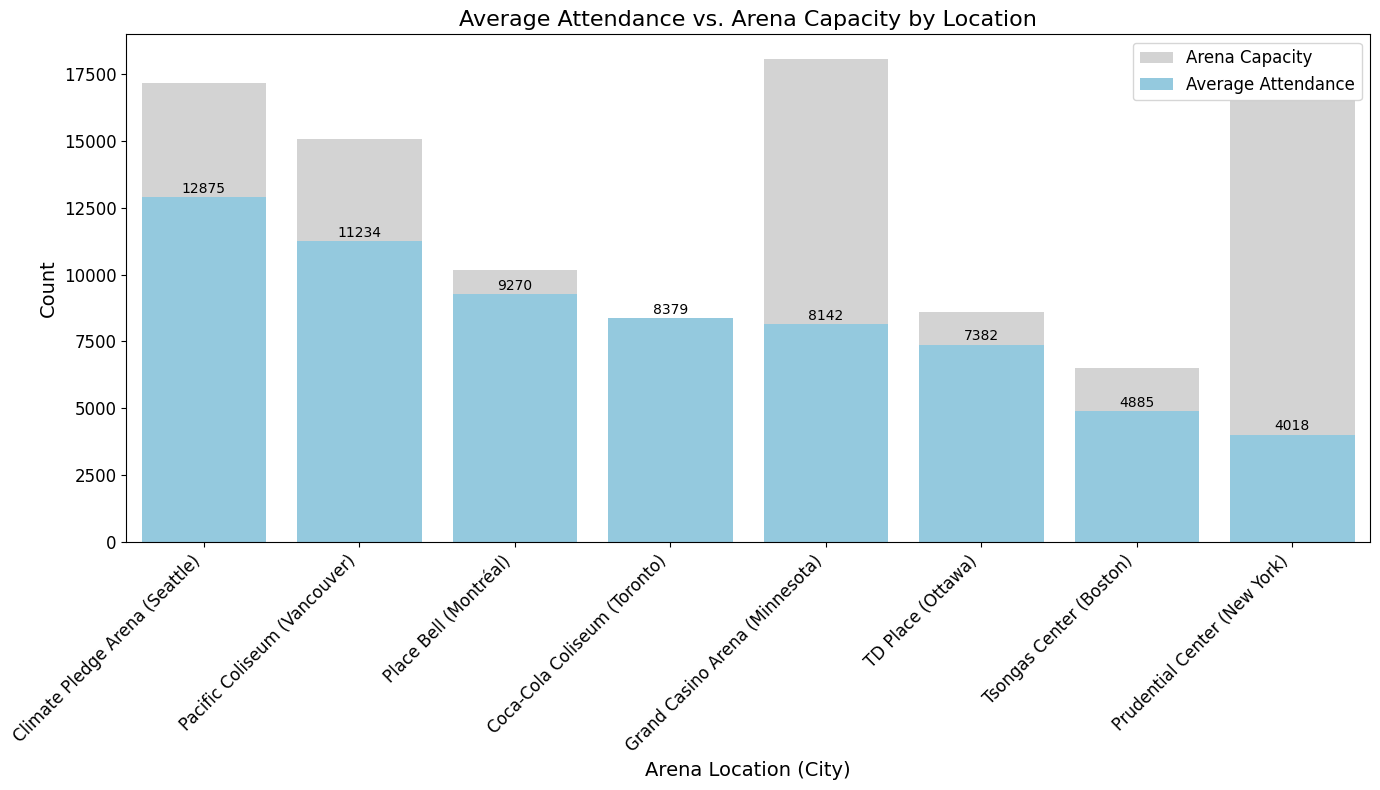

In [194]:
fig = plot_arena_average_attendance_vs_capacity(average_attendance_by_location, arena_capacities_df)
fig.savefig('graphs/primary_venue_averages_vs_capacity.png', dpi=300, bbox_inches='tight')

## Attendances Per Game For Primary Venues

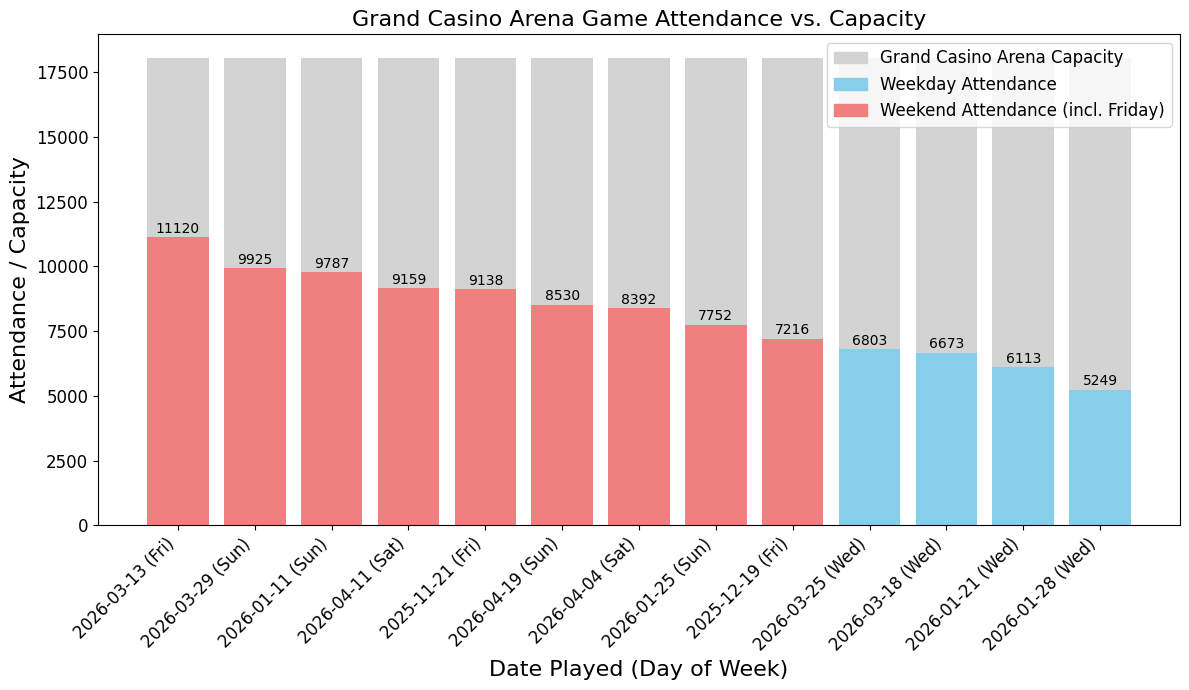

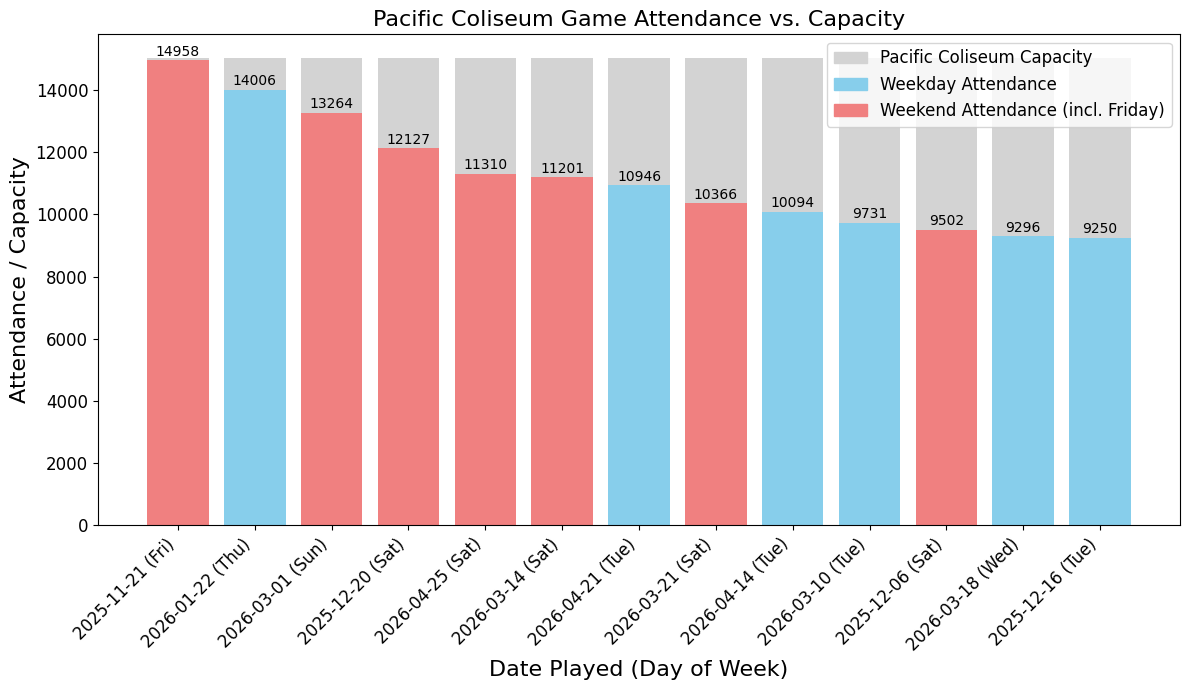

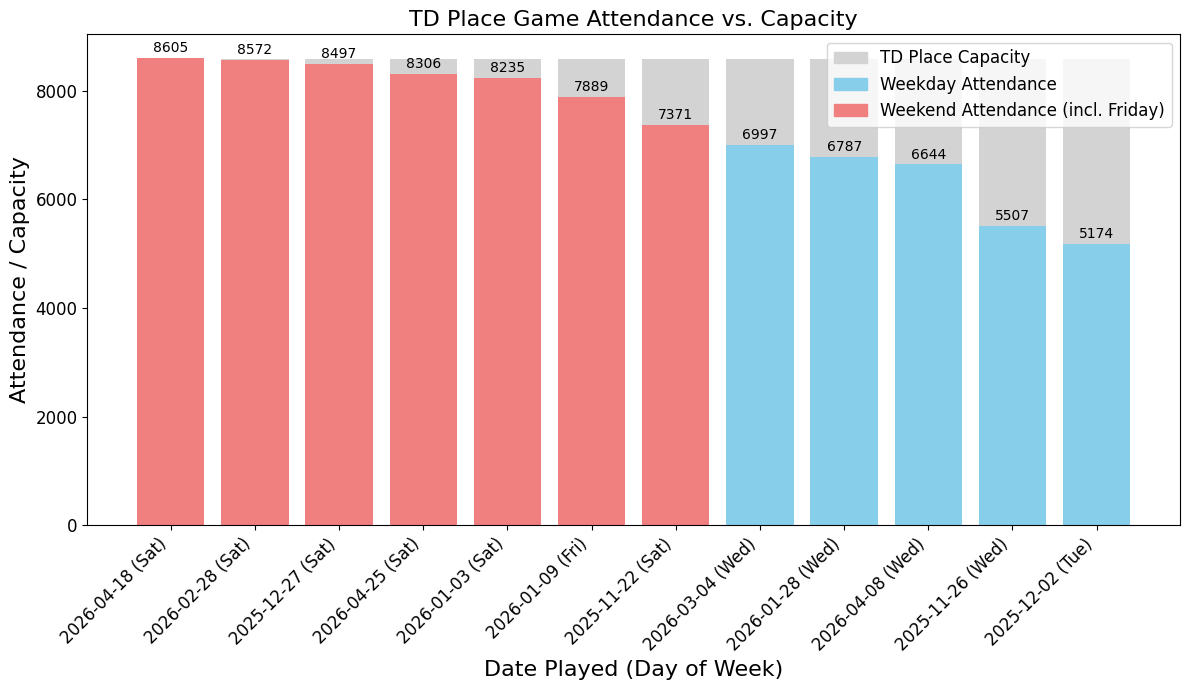

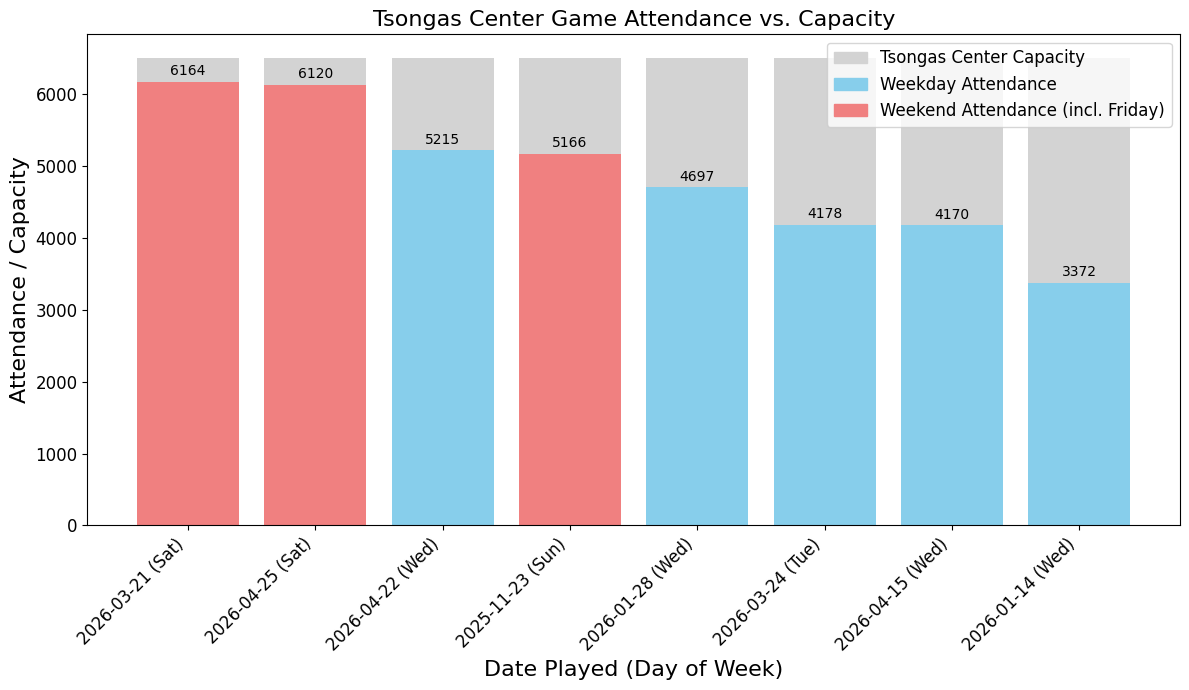

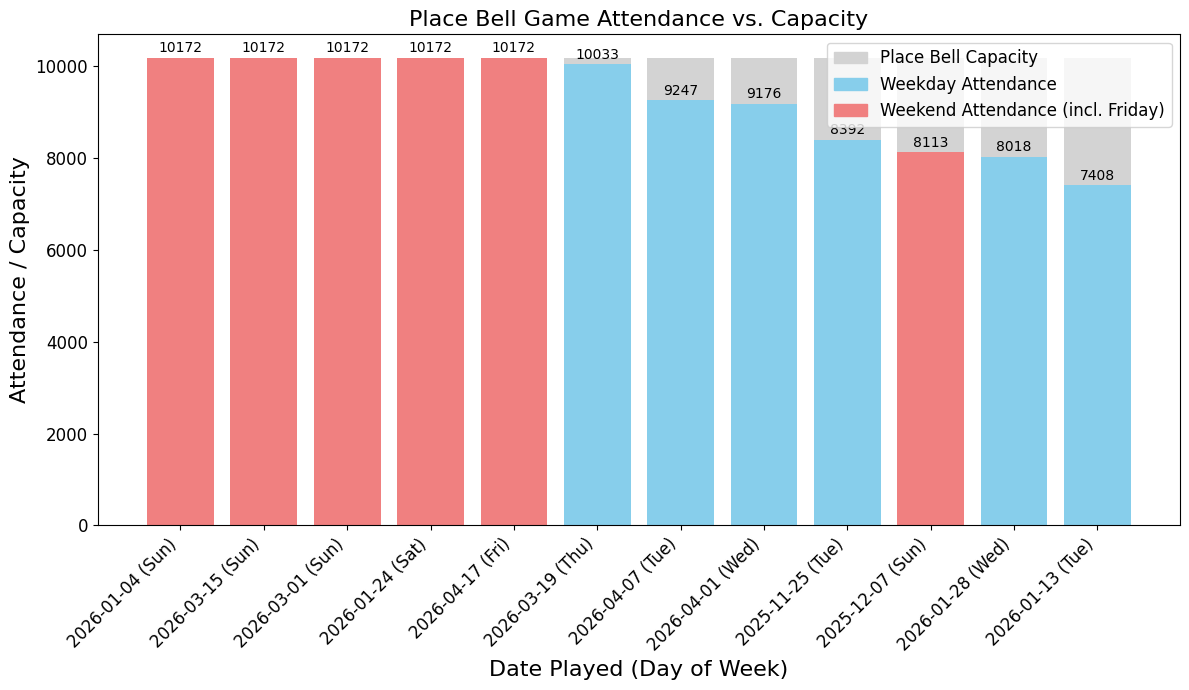

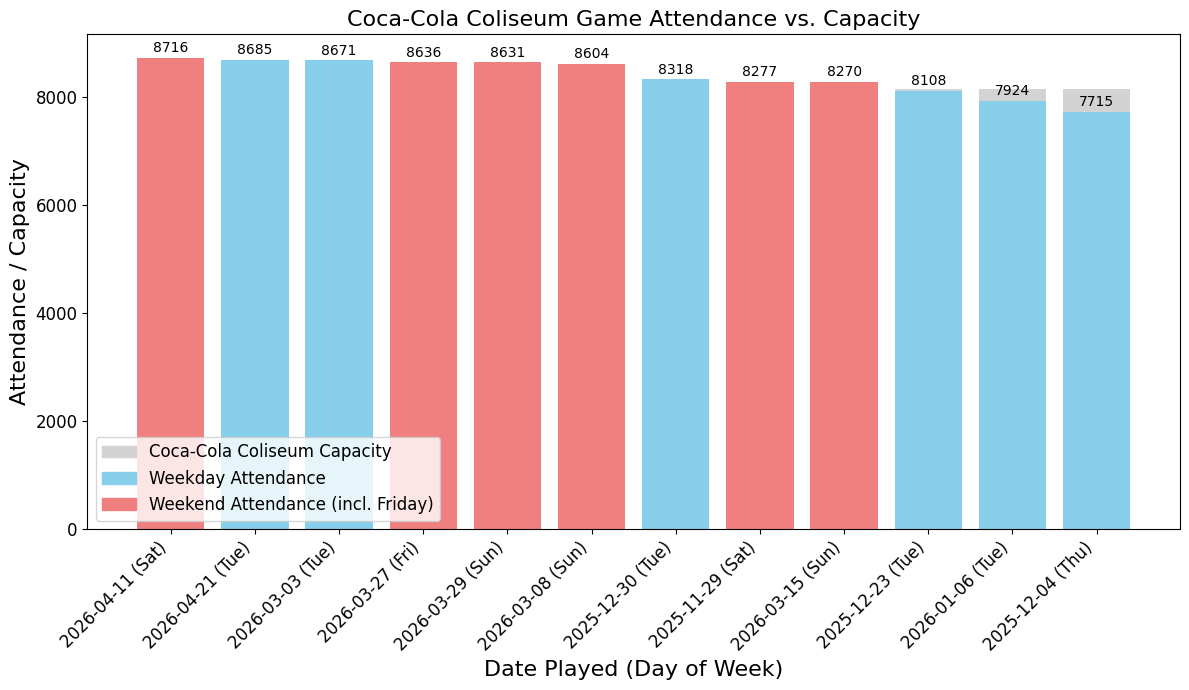

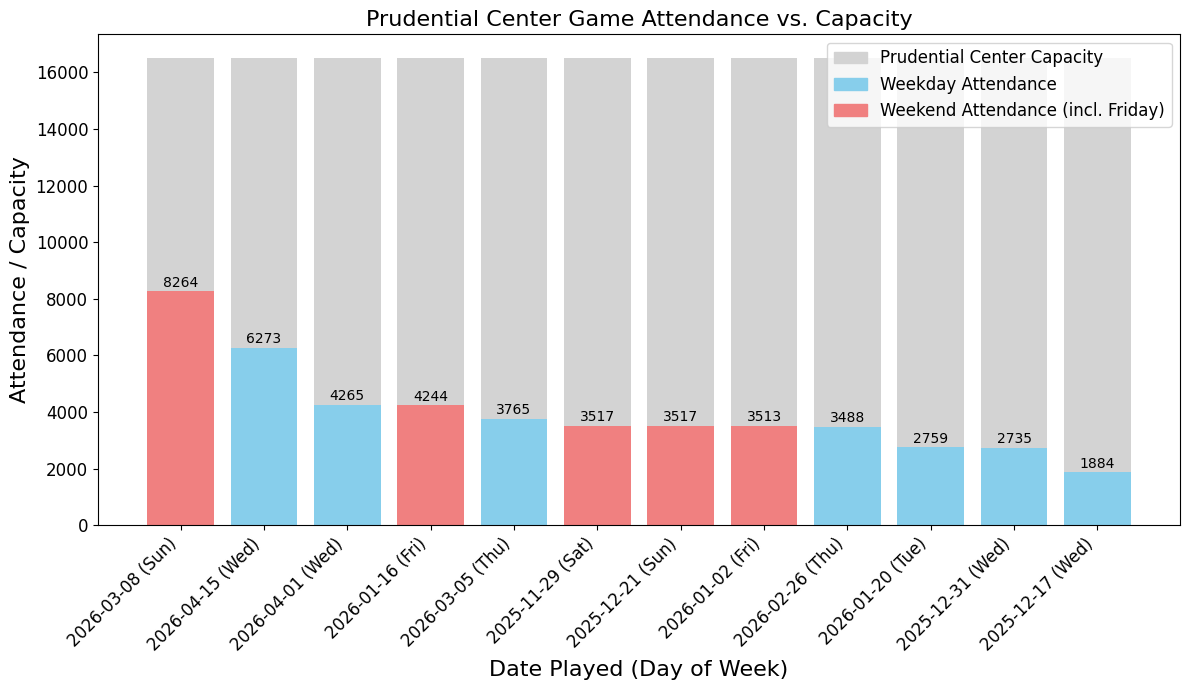

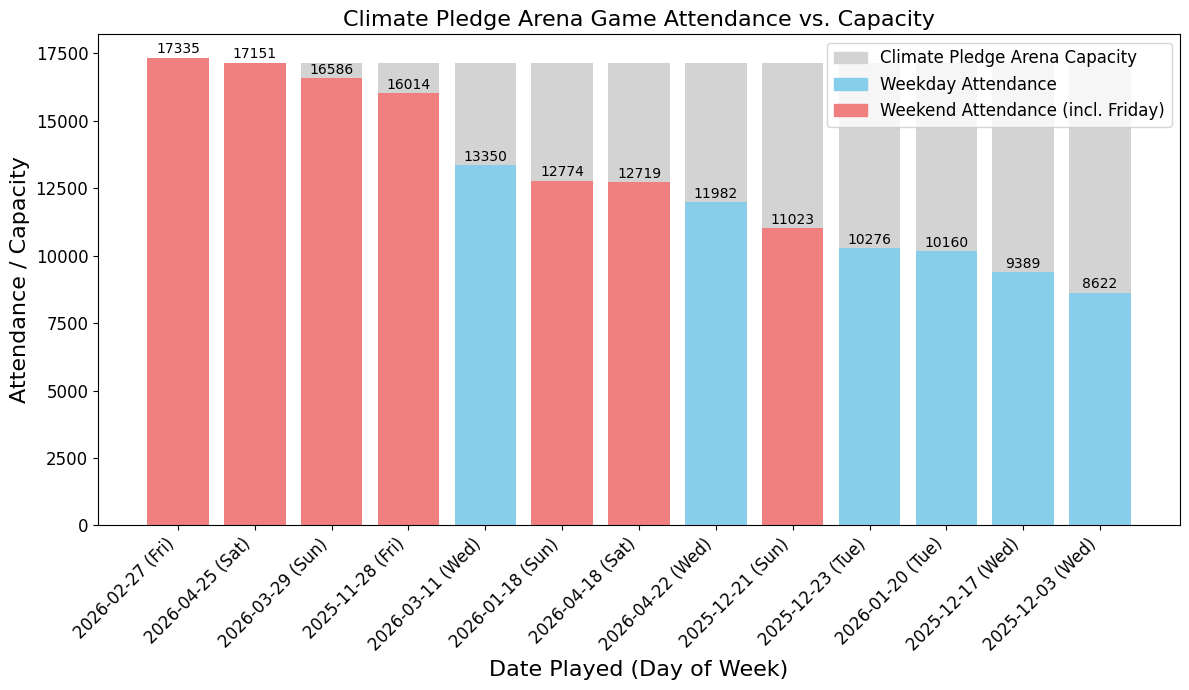

In [195]:
for arena_name in primary_location_name_map.values():
    fig = plot_arena_attendance_vs_capacity(arena_name, s3_regular_season_primary_venue_attendance_data, arena_capacities_df)
    fig.savefig('graphs/'+arena_name+'.png', dpi=300, bbox_inches='tight')